<a href="https://colab.research.google.com/github/SHRUTI-BARUA/SPELL-CHECKER/blob/main/SPELL_CHECKER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Mounted at /content/drive
Dataset Loaded
Total tokens: 2272
Vocabulary size: 618

MODEL RESULTS

Unigram: 0.599999999994 0.9999999999833333 0.74999999994375
Bigram: 0.599999999994 0.9999999999833333 0.74999999994375
Trigram: 0.399999999992 0.33333333332777776 0.36363636358016527

Runtime
Unigram: 0.09997296333312988
Bigram: 0.11547017097473145
Trigram: 0.046448707580566406


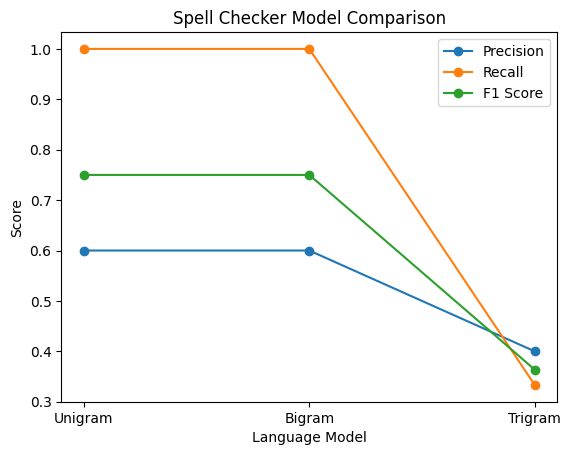


Example
Original: wifi singal is weak
Unigram: wifi signal is weak
Bigram: wifi signal is weak
Trigram: wifi singal is weak


In [ ]:


!pip install pandas nltk > /dev/null

import pandas as pd
import re
import time
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.metrics.distance import edit_distance
from google.colab import drive

nltk.download('punkt')

# ----------------------------
# MOUNT GOOGLE DRIVE
# ----------------------------
drive.mount('/content/drive')

path="/content/drive/MyDrive/sample.csv"
data=pd.read_csv(path)

print("Dataset Loaded")

# ----------------------------
# BUILD CORPUS
# ----------------------------
corpus=""

for col in data.columns:
    corpus+=" ".join(data[col].astype(str))+" "

# ----------------------------
# CLEAN TEXT
# ----------------------------
def clean_text(text):
    text=text.lower()
    return re.findall(r'\b[a-z]+\b',text)

tokens=clean_text(corpus)

print("Total tokens:",len(tokens))

# ----------------------------
# VOCABULARY
# ----------------------------
vocab=set(tokens)

extra_words=[
"wifi","signal","disconnecting","connection",
"password","internet","router","firmware",
"ethernet","network","update","weak"
]

for w in extra_words:
    vocab.add(w)

print("Vocabulary size:",len(vocab))

# ----------------------------
# UNIGRAM MODEL
# ----------------------------
unigram_counts=Counter(tokens)
total_words=sum(unigram_counts.values())

def unigram_prob(word):
    return (unigram_counts[word]+1)/(total_words+len(vocab))

# ----------------------------
# BIGRAM MODEL
# ----------------------------
bigrams=list(ngrams(tokens,2))
bigram_counts=Counter(bigrams)

def bigram_prob(w1,w2):
    return (bigram_counts[(w1,w2)]+1)/(unigram_counts[w1]+len(vocab))


# TRIGRAM MODEL

trigrams=list(ngrams(tokens,3))
trigram_counts=Counter(trigrams)

def trigram_prob(w1,w2,w3):
    return (trigram_counts[(w1,w2,w3)]+1)/(bigram_counts[(w1,w2)]+len(vocab))


def generate_candidates(word):

    if word in vocab:
        return [word]

    # distance 1 first
    cands=[v for v in vocab if abs(len(v)-len(word))<=1 and edit_distance(word,v)==1]

    if cands:
        return cands

    # distance 2
    cands=[v for v in vocab if abs(len(v)-len(word))<=2 and edit_distance(word,v)==2]

    return cands if cands else [word]


def correct_unigram(word):

    if word in vocab:
        return word

    candidates=generate_candidates(word)

    best_word=word
    best_score=-1

    for c in candidates:
        score=unigram_prob(c)

        if score>best_score:
            best_score=score
            best_word=c

    return best_word


def correct_bigram(prev_word,word):

    if word in vocab:
        return word

    candidates=generate_candidates(word)

    best_word=word
    best_score=-1

    for c in candidates:
        score=bigram_prob(prev_word,c)

        if score>best_score:
            best_score=score
            best_word=c

    return best_word


def correct_trigram(w1,w2,word):

    if word in vocab:
        return word

    candidates=generate_candidates(word)

    best_word=word
    best_score=-1

    for c in candidates:

        if (w1,w2,c) in trigram_counts:
            score=trigram_prob(w1,w2,c)*100

        elif (w2,c) in bigram_counts:
            score=bigram_prob(w2,c)*10

        else:
            score=unigram_prob(c)

        if score>best_score:
            best_score=score
            best_word=c

    return best_word

# ----------------------------
# TOKENIZER
# ----------------------------
def tokenize(sentence):
    return re.findall(r'\b[a-z]+\b',sentence.lower())

# ----------------------------
# SENTENCE CORRECTION
# ----------------------------
def correct_sentence_unigram(sentence):

    words=tokenize(sentence)

    return " ".join([correct_unigram(w) for w in words])


def correct_sentence_bigram(sentence):

    words=tokenize(sentence)

    corrected=[words[0]]

    for i in range(1,len(words)):
        corrected.append(correct_bigram(corrected[i-1],words[i]))

    return " ".join(corrected)


def correct_sentence_trigram(sentence):

    words=tokenize(sentence)

    if len(words)<3:
        return correct_sentence_bigram(sentence)

    corrected=words[:2]

    for i in range(2,len(words)):
        corrected.append(correct_trigram(corrected[i-2],corrected[i-1],words[i]))

    return " ".join(corrected)

# ----------------------------
# TEST SET
# ----------------------------
test_sentences=[

("wifi singal is weak","wifi signal is weak"),
("router keeps disconecting","router keeps disconnecting"),
("check ethernet conection","check ethernet connection"),
("network passwrod incorrect","network password incorrect"),
("internet conection lost","internet connection lost"),
("router firmwere update failed","router firmware update failed")

]

# ----------------------------
# EVALUATION
# ----------------------------
def evaluate(model):

    TP=0
    FP=0
    FN=0

    for wrong,correct in test_sentences:

        pred=model(wrong)

        p=pred.split()
        t=correct.split()
        w=wrong.split()

        for pr,tr,orw in zip(p,t,w):

            if orw!=tr:

                if pr==tr:
                    TP+=1
                else:
                    FN+=1

            else:

                if pr!=tr:
                    FP+=1

    precision=TP/(TP+FP+1e-10)
    recall=TP/(TP+FN+1e-10)
    f1=2*precision*recall/(precision+recall+1e-10)

    return precision,recall,f1

# ----------------------------
# MODEL COMPARISON
# ----------------------------
p1,r1,f1=evaluate(correct_sentence_unigram)
p2,r2,f2=evaluate(correct_sentence_bigram)
p3,r3,f3=evaluate(correct_sentence_trigram)

print("\nMODEL RESULTS\n")

print("Unigram:",p1,r1,f1)
print("Bigram:",p2,r2,f2)
print("Trigram:",p3,r3,f3)

# ----------------------------
# RUNTIME TEST
# ----------------------------
def runtime_test(model):

    start=time.time()

    for s,_ in test_sentences:
        model(s)

    return time.time()-start

t1=runtime_test(correct_sentence_unigram)
t2=runtime_test(correct_sentence_bigram)
t3=runtime_test(correct_sentence_trigram)

print("\nRuntime")
print("Unigram:",t1)
print("Bigram:",t2)
print("Trigram:",t3)

# ----------------------------
# GRAPH
# ----------------------------
models=["Unigram","Bigram","Trigram"]

precision=[p1,p2,p3]
recall=[r1,r2,r3]
f1=[f1,f2,f3]

plt.plot(models,precision,marker='o',label="Precision")
plt.plot(models,recall,marker='o',label="Recall")
plt.plot(models,f1,marker='o',label="F1 Score")

plt.title("Spell Checker Model Comparison")
plt.xlabel("Language Model")
plt.ylabel("Score")

plt.legend()
plt.show()


sentence="wifi singal is weak"

print("\nExample")
print("Original:",sentence)
print("Unigram:",correct_sentence_unigram(sentence))
print("Bigram:",correct_sentence_bigram(sentence))
print("Trigram:",correct_sentence_trigram(sentence))

In [ ]:
!pip install pandas nltk

In [ ]:
import pandas as pd
import re
import time
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.metrics.distance import edit_distance

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/sample.csv"

data = pd.read_csv(path)

print(data.head())

   tweet_id     author_id  inbound                      created_at  \
0    119237        105834     True  Wed Oct 11 06:55:44 +0000 2017   
1    119238  ChaseSupport    False  Wed Oct 11 13:25:49 +0000 2017   
2    119239        105835     True  Wed Oct 11 13:00:09 +0000 2017   
3    119240  VirginTrains    False  Tue Oct 10 15:16:08 +0000 2017   
4    119241        105836     True  Tue Oct 10 15:17:21 +0000 2017   

                                                text response_tweet_id  \
0  @AppleSupport causing the reply to be disregar...            119236   
1  @105835 Your business means a lot to us. Pleas...               NaN   
2  @76328 I really hope you all change but I'm su...            119238   
3  @105836 LiveChat is online at the moment - htt...            119241   
4  @VirginTrains see attached error message. I've...            119243   

   in_response_to_tweet_id  
0                      NaN  
1                 119239.0  
2                      NaN  
3                 

In [ ]:
corpus = ""

for col in data.columns:
    corpus += " ".join(data[col].astype(str)) + " "

print(len(corpus))

17337


In [ ]:
def clean_text(text):

    text = text.lower()

    words = re.findall(r'\b[a-z]+\b', text)

    return words

tokens = clean_text(corpus)

print("Total Tokens:", len(tokens))

Total Tokens: 2272


In [ ]:
vocab = set(tokens)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 609


In [ ]:
extra_words = [
"wifi","signal","disconnecting","connection",
"password","internet","router","firmware",
"ethernet","network","update","weak"
]

for w in extra_words:
    vocab.add(w)

In [ ]:
unigram_counts = Counter(tokens)

total_words = sum(unigram_counts.values())

def unigram_prob(word):

    return (unigram_counts[word] + 1) / (total_words + len(vocab))

In [ ]:
bigrams = list(ngrams(tokens,2))

bigram_counts = Counter(bigrams)

def bigram_prob(w1,w2):

    return (bigram_counts[(w1,w2)] + 1) / (unigram_counts[w1] + len(vocab))

In [ ]:
trigrams = list(ngrams(tokens,3))

trigram_counts = Counter(trigrams)

def trigram_prob(w1,w2,w3):

    return (trigram_counts[(w1,w2,w3)] + 1) / (bigram_counts[(w1,w2)] + len(vocab))

In [ ]:
def generate_candidates(word):

    candidates = []

    for v in vocab:
        if edit_distance(word,v) <= 2:
            candidates.append(v)

    if len(candidates) == 0:

        for v in vocab:
            if edit_distance(word,v) <= 3:
                candidates.append(v)

    if len(candidates) == 0:
        candidates.append(word)

    return candidates

In [ ]:
def correct_unigram(word):

    candidates = generate_candidates(word)

    best_word = word
    best_score = 0

    for c in candidates:

        score = unigram_prob(c)

        if score > best_score:
            best_score = score
            best_word = c

    return best_word

In [ ]:
def correct_bigram(prev_word,word):

    candidates = generate_candidates(word)

    best_word = word
    best_score = 0

    for c in candidates:

        score = bigram_prob(prev_word,c)

        if score > best_score:
            best_score = score
            best_word = c

    return best_word

In [ ]:
def correct_trigram(w1,w2,word):

    candidates = generate_candidates(word)

    best_word = word
    best_score = 0

    for c in candidates:

        score = trigram_prob(w1,w2,c)

        if score > best_score:
            best_score = score
            best_word = c

    return best_word

In [ ]:
def tokenize(sentence):

    return re.findall(r'\b[a-z]+\b', sentence.lower())

In [ ]:
def correct_sentence_unigram(sentence):

    words = tokenize(sentence)

    corrected = [correct_unigram(w) for w in words]

    return " ".join(corrected)


def correct_sentence_bigram(sentence):

    words = tokenize(sentence)

    corrected = [words[0]]

    for i in range(1,len(words)):

        corrected.append(correct_bigram(corrected[i-1],words[i]))

    return " ".join(corrected)


def correct_sentence_trigram(sentence):

    words = tokenize(sentence)

    if len(words) < 3:
        return correct_sentence_bigram(sentence)

    corrected = words[:2]

    for i in range(2,len(words)):

        corrected.append(correct_trigram(corrected[i-2],corrected[i-1],words[i]))

    return " ".join(corrected)

In [ ]:
test_sentences = [

("wifi singal is weak","wifi signal is weak"),
("router keeps disconecting","router keeps disconnecting"),
("check ethernet conection","check ethernet connection"),
("network passwrod incorrect","network password incorrect"),
("internet conection lost","internet connection lost"),
("router firmwere update failed","router firmware update failed")

]

In [ ]:
def evaluate(model):

    TP = 0
    FP = 0
    FN = 0

    for wrong,correct in test_sentences:

        prediction = model(wrong)

        p = prediction.split()
        t = correct.split()
        w = wrong.split()

        for pred,true,orig in zip(p,t,w):

            if orig != true:

                if pred == true:
                    TP += 1
                else:
                    FN += 1

            else:

                if pred != true:
                    FP += 1

    precision = TP/(TP+FP+1e-10)
    recall = TP/(TP+FN+1e-10)

    f1 = 2*precision*recall/(precision+recall+1e-10)

    return precision,recall,f1

In [ ]:
p1,r1,f1 = evaluate(correct_sentence_unigram)
p2,r2,f2 = evaluate(correct_sentence_bigram)
p3,r3,f3 = evaluate(correct_sentence_trigram)

print("MODEL COMPARISON RESULTS\n")

print("Unigram:",p1,r1,f1)
print("Bigram:",p2,r2,f2)
print("Trigram:",p3,r3,f3)

MODEL COMPARISON RESULTS

Unigram: 0.42857142856836733 0.9999999999833333 0.599999999952
Bigram: 0.49999999999583333 0.9999999999833333 0.6666666666148148
Trigram: 0.2857142857102041 0.33333333332777776 0.30769230763786976


In [ ]:
def runtime_test(model):

    start = time.time()

    for s,_ in test_sentences:
        model(s)

    return time.time() - start

t1 = runtime_test(correct_sentence_unigram)
t2 = runtime_test(correct_sentence_bigram)
t3 = runtime_test(correct_sentence_trigram)

print("\nRuntime Comparison (seconds)")
print("Unigram:",t1)
print("Bigram:",t2)
print("Trigram:",t3)


Runtime Comparison (seconds)
Unigram: 0.5203588008880615
Bigram: 0.24331879615783691
Trigram: 0.13712120056152344


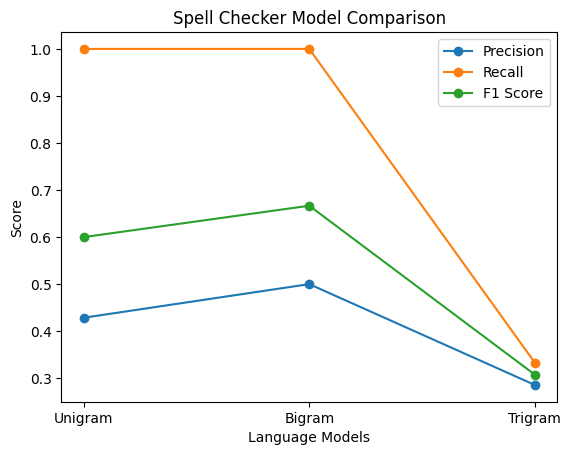

In [ ]:
models = ["Unigram","Bigram","Trigram"]

precision = [p1,p2,p3]
recall = [r1,r2,r3]
f1_scores = [f1,f2,f3]

plt.plot(models,precision,marker='o',label="Precision")
plt.plot(models,recall,marker='o',label="Recall")
plt.plot(models,f1_scores,marker='o',label="F1 Score")

plt.xlabel("Language Models")
plt.ylabel("Score")
plt.title("Spell Checker Model Comparison")

plt.legend()

plt.show()

In [ ]:
sentence = "wifi singal is weak"

print("Original:",sentence)

print("Unigram:",correct_sentence_unigram(sentence))
print("Bigram:",correct_sentence_bigram(sentence))
print("Trigram:",correct_sentence_trigram(sentence))

Original: wifi singal is weak
Unigram: if signal i wed
Bigram: wifi signal bit weak
Trigram: wifi singal bit weak
